# Lorenz63 MLP Residual Training Cookbook

This notebook trains the current `models.py` MLP residual Neural ODE model. The model uses an unconstrained learnable linear matrix plus an MLP residual component:

`f_theta(x) = A_theta x + G_theta(x)`

The default residual mask in `models.py` is `(1, 1, 1)`, so the residual component is not told the Lorenz63 nonlinear sparsity constraint.

In [29]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.optim import AdamW

repo_root = Path.cwd()
if repo_root.name == "examples":
    repo_root = repo_root.parent

src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from lorenz63_neuralode.data import get_dataloaders
from lorenz63_neuralode.models import build_lorenz63_model

torch.manual_seed(42)
plt.rcParams.update({"figure.dpi": 120})

repo_root

PosixPath('/srv/data/kezhoulumelody/Lorenz63_NeuralODE')

## Configuration

`MODEL_NAME = "residual_mlp"` builds `Lorenz63ResidualModel` from the current unstructured `models.py`.

In [ ]:
MODEL_NAME = "attention"

DATA_PATH = repo_root / "data" / "lorenz63_trajectory_10-28-2.7.npz"


SIGMA_INIT = 9
RHO_INIT = 29
BETA_INIT = 2
HIDDEN_DIM = 32
N_HIDDEN_LAYERS = 1

BATCH_SIZE = 256
N_EPOCHS = 450
LR = 1e-3
WEIGHT_DECAY = 1e-3
LAMBDA_A = 5e-4
USE_STATS_REGULARIZATION = False
LAMBDA_STATS = 5e-4
ROLLOUT_STATS_STEPS = 25
ROLLOUT_STATS_BATCH = 8

# User-supplied linear operator used only as the regularization target.
# This can be different from SIGMA_INIT/RHO_INIT/BETA_INIT, which only initialize the model.
A_GIVEN = torch.tensor(
    [
        [-10.0, 10.0, 0.0],
        [28.0, -1.0, 0.0],
        [0.0, 0.0, -8.0 / 3.0],
    ],
    dtype=torch.float32,
)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

stats_tag = f".statsReg{LAMBDA_STATS:g}" if USE_STATS_REGULARIZATION else ""
OUTPUT_DIR = repo_root / "outputs" / "unstructured" / f"lorenz63_{MODEL_NAME}.hidden{HIDDEN_DIM}.layers{N_HIDDEN_LAYERS}.normalizedLoss.linearReg{LAMBDA_A:g}{stats_tag}"

# OUTPUT_DIR = repo_root / "outputs" / "unstructured" / f"lorenz63_{MODEL_NAME}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SAVE_ARTIFACTS = True
CHECKPOINT_PATH = OUTPUT_DIR / f"lorenz63_{MODEL_NAME}_10-28-2.7_{SIGMA_INIT}-{RHO_INIT}-{BETA_INIT}.pt"
CURVE_PATH = OUTPUT_DIR / f"lorenz63_{MODEL_NAME}_10-28-2.7_{SIGMA_INIT}-{RHO_INIT}-{BETA_INIT}_curves.png"

print(f"device: {DEVICE}")
print(f"data: {DATA_PATH}")
print(f"output: {OUTPUT_DIR}")
print(f"lambda_A: {LAMBDA_A}")
print(f"use_stats_regularization: {USE_STATS_REGULARIZATION}")
print(f"lambda_stats: {LAMBDA_STATS}")
print(f"rollout stats steps: {ROLLOUT_STATS_STEPS}, batch: {ROLLOUT_STATS_BATCH}")
print(f"A_GIVEN:\n{A_GIVEN}")


device: cuda
data: /srv/data/kezhoulumelody/Lorenz63_NeuralODE/data/lorenz63_trajectory_10-28-2.7.npz
output: /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/unstructured/lorenz63_transformer.hidden32.layers1.normalizedLoss.linearReg0.0005
lambda_A: 0.0005
use_stats_regularization: False
lambda_stats: 0.0005
rollout stats steps: 25, batch: 8
A_GIVEN:
tensor([[-10.0000,  10.0000,   0.0000],
        [ 28.0000,  -1.0000,   0.0000],
        [  0.0000,   0.0000,  -2.6667]])


## Load Data And Build Model

In [31]:
train_loader, test_loader = get_dataloaders(
    npz_path=DATA_PATH,
    batch_size=BATCH_SIZE,
)

model = build_lorenz63_model(
    model_name=MODEL_NAME,
    sigma_init=SIGMA_INIT,
    rho_init=RHO_INIT,
    beta_init=BETA_INIT,
    hidden_dim=HIDDEN_DIM,
    n_hidden_layers=N_HIDDEN_LAYERS,
).to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

n_train = len(train_loader.dataset)
n_test = len(test_loader.dataset)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"train samples: {n_train}, test samples: {n_test}")
print(f"trainable parameters: {n_params}")
print(f"initial learned A:\n{model.A.detach().cpu()}")
print(f"residual mask: {model.residual_mask.detach().cpu().tolist()}")


Lorenz63TransformerResidualModel(
  (linear): UnstructuredLorenz63Linear()
  (input_proj): Linear(in_features=1, out_features=32, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (output_proj): Linear(in_features=32, out_features=1, bias=True)
)
train samples: 80000, test samples: 20000
trainable parameters: 8746
initial learned A:
tensor([[-9

## Metric Helpers

`compute_tendency_component_scale` mirrors `train.py`: it computes the training-set standard deviation of `dx/dt`, `dy/dt`, and `dz/dt` so the loss can normalize each component before taking MSE.

`rollout_state_statistics_loss` performs a short differentiable RK4 rollout and compares learned-vs-true state mean and variance.

`evaluate_split` returns overall RMSE, component-wise RMSE for `dx/dt`, `dy/dt`, and `dz/dt`, plus overall and component-wise anomaly correlation coefficient.

In [32]:
def compute_tendency_component_scale(train_loader, device, eps=1e-8):
    """Compute per-component target tendency scales from the training split."""
    total = torch.zeros(3, device=device)
    total_sq = torch.zeros(3, device=device)
    n_samples = 0

    for batch in train_loader:
        target_dxdt = batch["dxdt"].to(device)
        total += torch.sum(target_dxdt, dim=0)
        total_sq += torch.sum(target_dxdt ** 2, dim=0)
        n_samples += target_dxdt.shape[0]

    if n_samples == 0:
        raise ValueError("Cannot compute tendency component scales from an empty train loader.")

    mean = total / n_samples
    variance = torch.clamp(total_sq / n_samples - mean ** 2, min=eps ** 2)
    return torch.sqrt(variance)


def rk4_step_batch(model, x, dt):
    """One differentiable fixed-step RK4 update for a batch of states."""
    k1 = model(x)
    k2 = model(x + 0.5 * dt * k1)
    k3 = model(x + 0.5 * dt * k2)
    k4 = model(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


def rk4_rollout_batch(model, initial_states, dt, n_steps):
    """Roll out a batch of initial states and return shape [n_steps + 1, batch, 3]."""
    states = [initial_states]
    current = initial_states
    for _ in range(n_steps):
        current = rk4_step_batch(model, current, dt)
        states.append(current)
    return torch.stack(states, dim=0)


def rollout_state_statistics_loss(model, true_states, dt, n_steps, batch_size, state_scale):
    """Compare short learned rollout mean/variance against matching true trajectory windows."""
    max_start = true_states.shape[0] - n_steps - 1
    if max_start <= 0:
        raise ValueError("Not enough true states for the requested rollout statistics window.")

    starts = torch.randint(0, max_start, (batch_size,), device=true_states.device)
    offsets = torch.arange(n_steps + 1, device=true_states.device).unsqueeze(1)
    window_indices = starts.unsqueeze(0) + offsets
    true_window = true_states[window_indices]

    learned_window = rk4_rollout_batch(model, true_window[0], dt, n_steps)

    learned_mean = learned_window.mean(dim=(0, 1))
    true_mean = true_window.mean(dim=(0, 1))
    learned_var = learned_window.var(dim=(0, 1), unbiased=False)
    true_var = true_window.var(dim=(0, 1), unbiased=False)

    mean_loss = torch.mean(((learned_mean - true_mean) / state_scale) ** 2)
    var_loss = torch.mean((learned_var - true_var) ** 2 / (state_scale ** 4))
    return mean_loss + var_loss


@torch.no_grad()
def evaluate_split(model, dataloader, device):
    model.eval()
    preds = []
    targets = []

    for batch in dataloader:
        state = batch["state"].to(device)
        target = batch["dxdt"].to(device)
        pred = model(state)
        preds.append(pred.detach().cpu())
        targets.append(target.detach().cpu())

    pred = torch.cat(preds, dim=0)
    target = torch.cat(targets, dim=0)
    err = pred - target

    eps = 1e-12
    rmse = torch.sqrt(torch.mean(err ** 2))
    component_rmse = torch.sqrt(torch.mean(err ** 2, dim=0))

    target_mean = torch.mean(target, dim=0, keepdim=True)
    pred_anom = pred - target_mean
    target_anom = target - target_mean

    acc_numerator = torch.sum(pred_anom * target_anom)
    acc_denominator = torch.sqrt(torch.sum(pred_anom ** 2) * torch.sum(target_anom ** 2)).clamp_min(eps)
    acc = acc_numerator / acc_denominator

    component_acc_numerator = torch.sum(pred_anom * target_anom, dim=0)
    component_acc_denominator = torch.sqrt(
        torch.sum(pred_anom ** 2, dim=0) * torch.sum(target_anom ** 2, dim=0)
    ).clamp_min(eps)
    component_acc = component_acc_numerator / component_acc_denominator

    return {
        "rmse": float(rmse),
        "component_rmse": [float(v) for v in component_rmse],
        "acc": float(acc),
        "component_acc": [float(v) for v in component_acc],
    }


def append_metrics(history, prefix, metrics):
    history[f"{prefix}_rmse"].append(metrics["rmse"])
    history[f"{prefix}_component_rmse"].append(metrics["component_rmse"])
    history[f"{prefix}_acc"].append(metrics["acc"])
    history[f"{prefix}_component_acc"].append(metrics["component_acc"])

## Train

The loop uses normalized component tendency MSE for data fitting and adds `lambda_A * ||A_theta - A_given||^2`. If `USE_STATS_REGULARIZATION` is enabled, it also adds a short-rollout state statistics term comparing learned-vs-true mean and variance. Evaluation metrics remain in the original physical units.

In [33]:
component_scale = compute_tendency_component_scale(train_loader, DEVICE)
A_given = A_GIVEN.to(DEVICE)

if USE_STATS_REGULARIZATION:
    archive = np.load(DATA_PATH)
    true_states_for_stats = torch.from_numpy(archive["states"].astype(np.float32)).to(DEVICE)
    true_dt = float(np.mean(np.diff(archive["t"])))
    state_scale = torch.std(true_states_for_stats, dim=0, unbiased=False).clamp_min(1e-8)
else:
    true_states_for_stats = None
    true_dt = None
    state_scale = None

print(
    "Training with normalized tendency MSE using component scales: "
    f"{component_scale[0]:.6f}, {component_scale[1]:.6f}, {component_scale[2]:.6f}"
)
print(f"Linear regularization lambda_A: {LAMBDA_A:g}")
print(f"Statistics regularization enabled: {USE_STATS_REGULARIZATION}")
if USE_STATS_REGULARIZATION:
    print(f"Statistics regularization lambda_stats: {LAMBDA_STATS:g}")
    print(f"Rollout stats dt: {true_dt:.6f}, steps: {ROLLOUT_STATS_STEPS}, batch: {ROLLOUT_STATS_BATCH}")
    print(f"State statistic scales: {state_scale.detach().cpu()}")
    print(f"A regularization target A_given:{  A_given.detach().cpu()}")

history = {
    "epoch": [],
    "train_loss": [],
    "train_data_loss": [],
    "train_linear_reg": [],
    "train_stats_reg": [],
    "train_normalized_rmse": [],
    "train_rmse": [],
    "test_rmse": [],
    "train_component_rmse": [],
    "test_component_rmse": [],
    "train_acc": [],
    "test_acc": [],
    "train_component_acc": [],
    "test_component_acc": [],
}

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    total_data_loss = 0.0
    total_linear_reg = 0.0
    total_stats_reg = 0.0
    n_samples = 0

    for batch in train_loader:
        state = batch["state"].to(DEVICE)
        target = batch["dxdt"].to(DEVICE)

        pred = model(state)
        normalized_error = (pred - target) / component_scale
        data_loss = torch.mean(normalized_error ** 2)
        linear_reg = torch.mean((model.A - A_given) ** 2)
        loss = data_loss + LAMBDA_A * linear_reg

        if USE_STATS_REGULARIZATION:
            stats_reg = rollout_state_statistics_loss(
                model,
                true_states=true_states_for_stats,
                dt=true_dt,
                n_steps=ROLLOUT_STATS_STEPS,
                batch_size=ROLLOUT_STATS_BATCH,
                state_scale=state_scale,
            )
            loss = loss + LAMBDA_STATS * stats_reg
        else:
            stats_reg = pred.new_tensor(0.0)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        batch_n = state.shape[0]
        total_loss += loss.item() * batch_n
        total_data_loss += data_loss.item() * batch_n
        total_linear_reg += linear_reg.item() * batch_n
        total_stats_reg += stats_reg.item() * batch_n
        n_samples += batch_n

    train_loss = total_loss / max(n_samples, 1)
    train_data_loss = total_data_loss / max(n_samples, 1)
    train_linear_reg = total_linear_reg / max(n_samples, 1)
    train_stats_reg = total_stats_reg / max(n_samples, 1)
    train_normalized_rmse = train_data_loss ** 0.5
    train_metrics = evaluate_split(model, train_loader, DEVICE)
    test_metrics = evaluate_split(model, test_loader, DEVICE)

    history["epoch"].append(epoch)
    history["train_loss"].append(float(train_loss))
    history["train_data_loss"].append(float(train_data_loss))
    history["train_linear_reg"].append(float(train_linear_reg))
    history["train_stats_reg"].append(float(train_stats_reg))
    history["train_normalized_rmse"].append(float(train_normalized_rmse))
    append_metrics(history, "train", train_metrics)
    append_metrics(history, "test", test_metrics)

    if epoch == 1 or epoch % 10 == 0 or epoch == N_EPOCHS:
        message = (
            f"epoch {epoch:04d} | "
            f"loss {train_loss:.6f} | "
            f"data {train_data_loss:.6f} | "
            f"A_reg {train_linear_reg:.6f} | "
        )
        if USE_STATS_REGULARIZATION:
            message += f"stats {train_stats_reg:.6f} | "
        message += (
            f"normalized RMSE {train_normalized_rmse:.6f} | "
            f"train RMSE {train_metrics['rmse']:.6f} | "
            f"test RMSE {test_metrics['rmse']:.6f} | "
            f"train ACC {train_metrics['acc']:.4f} | "
            f"test ACC {test_metrics['acc']:.4f}"
        )
        print(message)


Training with normalized tendency MSE using component scales: 43.112057, 66.142006, 79.642311
Linear regularization lambda_A: 0.0005
Statistics regularization enabled: False
epoch 0001 | loss 5.076079 | data 5.075881 | A_reg 0.394501 | normalized RMSE 2.252972 | train RMSE 145.861053 | test RMSE 144.626801 | train ACC -0.1536 | test ACC -0.1400
epoch 0010 | loss 0.230469 | data 0.229889 | A_reg 1.160053 | normalized RMSE 0.479468 | train RMSE 28.848080 | test RMSE 28.227180 | train ACC 0.8953 | test ACC 0.8991
epoch 0020 | loss 0.015240 | data 0.014497 | A_reg 1.486069 | normalized RMSE 0.120403 | train RMSE 8.471512 | test RMSE 8.438310 | train ACC 0.9915 | test ACC 0.9915
epoch 0030 | loss 0.007591 | data 0.006628 | A_reg 1.926067 | normalized RMSE 0.081411 | train RMSE 5.406218 | test RMSE 5.442307 | train ACC 0.9965 | test ACC 0.9964
epoch 0040 | loss 0.005351 | data 0.004332 | A_reg 2.037710 | normalized RMSE 0.065822 | train RMSE 3.968964 | test RMSE 4.119578 | train ACC 0.9981 |

## Learning Curves

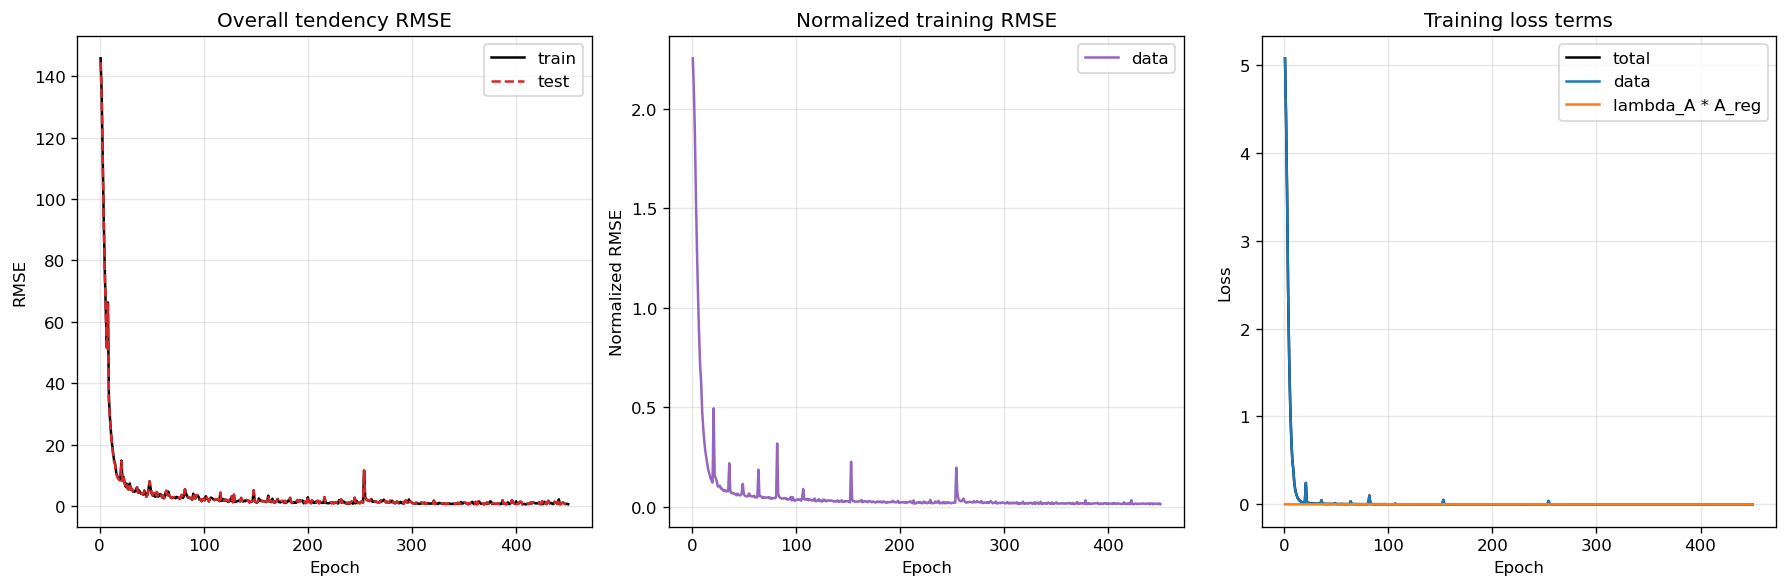

In [34]:
epochs = history["epoch"]
component_names = ("dx/dt", "dy/dt", "dz/dt")
component_colors = ("tab:blue", "tab:orange", "tab:green")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(epochs, history["train_rmse"], label="train", color="black")
axes[0].plot(epochs, history["test_rmse"], label="test", color="tab:red", linestyle="--")
axes[0].set_title("Overall tendency RMSE")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("RMSE")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_normalized_rmse"], label="data", color="tab:purple")
axes[1].set_title("Normalized training RMSE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Normalized RMSE")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(epochs, history["train_loss"], label="total", color="black")
axes[2].plot(epochs, history["train_data_loss"], label="data", color="tab:blue")
axes[2].plot(epochs, [LAMBDA_A * v for v in history["train_linear_reg"]], label="lambda_A * A_reg", color="tab:orange")
if USE_STATS_REGULARIZATION:
    axes[2].plot(epochs, [LAMBDA_STATS * v for v in history["train_stats_reg"]], label="lambda_stats * stats", color="tab:green")
axes[2].set_title("Training loss terms")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.tight_layout()
# if SAVE_ARTIFACTS:
#     fig.savefig(CURVE_PATH, dpi=200)
#     print(f"saved curves to {CURVE_PATH}")
plt.show()


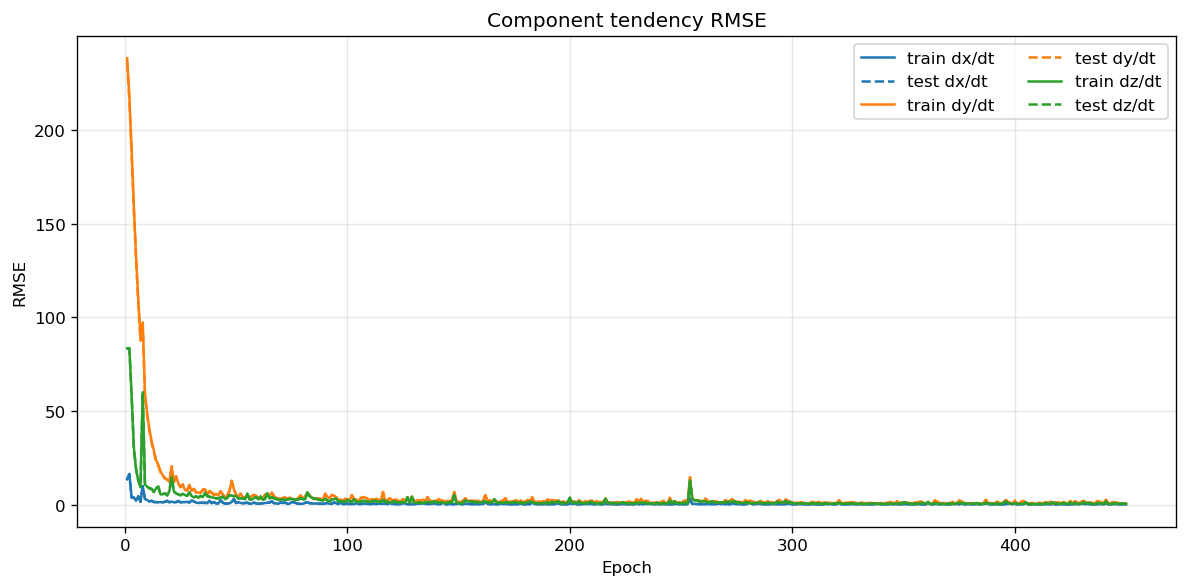

In [35]:
train_component_rmse = torch.tensor(history["train_component_rmse"])
test_component_rmse = torch.tensor(history["test_component_rmse"])

fig, ax = plt.subplots(figsize=(10, 5))

for idx, (name, color) in enumerate(zip(component_names, component_colors)):
    ax.plot(epochs, train_component_rmse[:, idx], label=f"train {name}", color=color)
    ax.plot(epochs, test_component_rmse[:, idx], label=f"test {name}", color=color, linestyle="--")

ax.set_title("Component tendency RMSE")
ax.set_xlabel("Epoch")
ax.set_ylabel("RMSE")
ax.legend(ncol=2)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Final Metrics

In [36]:
final = {
    "train_loss": history["train_loss"][-1],
    "train_data_loss": history["train_data_loss"][-1],
    "train_linear_reg": history["train_linear_reg"][-1],
    "train_stats_reg": history["train_stats_reg"][-1],
    "train_normalized_rmse": history["train_normalized_rmse"][-1],
    "train_rmse": history["train_rmse"][-1],
    "test_rmse": history["test_rmse"][-1],
    "train_acc": history["train_acc"][-1],
    "test_acc": history["test_acc"][-1],
    "train_component_rmse": dict(zip(component_names, history["train_component_rmse"][-1])),
    "test_component_rmse": dict(zip(component_names, history["test_component_rmse"][-1])),
}

final


{'train_loss': 0.0001518820730620064,
 'train_data_loss': 0.0001437162925780285,
 'train_linear_reg': 0.016331560268998145,
 'train_stats_reg': 0.0,
 'train_normalized_rmse': 0.011988173029199592,
 'train_rmse': 0.6130684614181519,
 'test_rmse': 0.6651219725608826,
 'train_acc': 0.9999561905860901,
 'test_acc': 0.9999476075172424,
 'train_component_rmse': {'dx/dt': 0.4058309495449066,
  'dy/dt': 0.799676775932312,
  'dz/dt': 0.5686626434326172},
 'test_component_rmse': {'dx/dt': 0.4031960368156433,
  'dy/dt': 0.9130806922912598,
  'dz/dt': 0.5752202868461609}}

## Save Checkpoint

In [37]:
if SAVE_ARTIFACTS:
    checkpoint_params = {
        "model_name": MODEL_NAME,
        "sigma_init": SIGMA_INIT,
        "rho_init": RHO_INIT,
        "beta_init": BETA_INIT,
        "hidden_dim": HIDDEN_DIM,
        "n_hidden_layers": N_HIDDEN_LAYERS,
        "residual_mask": model.residual_mask.detach().cpu(),
        "learned_A": model.A.detach().cpu() if hasattr(model, "A") else None,
        "tendency_component_scale": component_scale.detach().cpu(),
        "lambda_A": LAMBDA_A,
        "A_given": A_given.detach().cpu(),
        "use_stats_regularization": USE_STATS_REGULARIZATION,
        "lambda_stats": LAMBDA_STATS,
        "rollout_stats_steps": ROLLOUT_STATS_STEPS,
        "rollout_stats_batch": ROLLOUT_STATS_BATCH,
        "rollout_stats_dt": true_dt,
        "state_statistic_scale": state_scale.detach().cpu() if state_scale is not None else None,
    }

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "history": history,
            "params": checkpoint_params,
        },
        CHECKPOINT_PATH,
    )
    print(f"saved checkpoint to {CHECKPOINT_PATH}")
    print("saved params:")
    print(checkpoint_params)


saved checkpoint to /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/unstructured/lorenz63_transformer.hidden32.layers1.normalizedLoss.linearReg0.0005/lorenz63_transformer_10-28-2.7_9-29-2.pt
saved params:
{'model_name': 'transformer', 'sigma_init': 9, 'rho_init': 29, 'beta_init': 2, 'hidden_dim': 32, 'n_hidden_layers': 1, 'residual_mask': tensor([1., 1., 1.]), 'learned_A': tensor([[-9.9736e+00,  9.9820e+00, -1.4864e-02],
        [ 2.7647e+01, -1.0697e+00, -1.1645e-01],
        [ 4.4613e-03,  6.4585e-03, -2.6241e+00]]), 'tendency_component_scale': tensor([43.1121, 66.1420, 79.6423]), 'lambda_A': 0.0005, 'A_given': tensor([[-10.0000,  10.0000,   0.0000],
        [ 28.0000,  -1.0000,   0.0000],
        [  0.0000,   0.0000,  -2.6667]]), 'use_stats_regularization': False, 'lambda_stats': 0.0005, 'rollout_stats_steps': 25, 'rollout_stats_batch': 8, 'rollout_stats_dt': None, 'state_statistic_scale': None}
